# Course Project: Stacking Regression Models

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In this course project, you will:

1. Load the Airbnb "listings" data set.
2. Use the stacking ensemble method to train four regressors.
3. Train and evaluate the same four individual regressors.
4. Compare the performance of the stacked ensemble model to that of the individual models.

**<font color='red'>Note: Some of the code cells in this notebook may take a while to run.</font>**

## Part 1: Load the Data Set

We will work with a preprocessed version of the Airbnb NYC "listings" data set. 

<b>Task</b>: In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`.

You will be working with the file named "airbnb_readytofit.csv.gz" that is located in a folder named "data".

In [2]:
# YOUR CODE HERE
## Cell 01 -- correct? runs without error

filename = os.path.join(os.getcwd(), "data","airbnb_readytofit.csv.gz")
df = pd.read_csv(filename, header=0)


## Part 2: Create Training and Test Data Sets

So far, we mostly focused on classification problems. For this exercise, you will focus on a regression problem and predict a continuous outcome.

Your model will predict the price of a listing; the label is going to be 'price'.

### Create Labeled Examples 

<b>Task</b>: Create labeled examples from DataFrame `df`. 
In the code cell below carry out the following steps:

* Get the `price` column from DataFrame `df` and assign it to the variable `y`. This will be our label.
* Get all other columns from DataFrame `df` and assign them to the variable `X`. These will be our features. 

In [3]:
# YOUR CODE HERE
## Cell 02 -- correct? runs without error

y = df['price']
X = df.drop(columns = 'price' , axis=1)

### Split Labeled Examples Into Training and Test Sets

<b>Task</b>: In the code cell below, create training and test sets out of the labeled examples. 

1. Use scikit-learn's `train_test_split()` function to create the data sets.

2. Specify:
    * A test set that is 30 percent of the size of the data set.
    * A seed value of '1234'. 
    

In [4]:
# YOUR CODE HERE
## Cell 03 -- correct? runs without error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=1234)

## Part 3: Use the Stacking Ensemble Method to Train Four Regression Models and Evaluate the Performance

You will use the scikit-learn `StackingRegressor` class. For more information, consult the online [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html).

First let's import `StackingRegressor`:

In [5]:
from sklearn.ensemble import StackingRegressor

In this part of the assignment, we will try to use four models jointly. In the code cell below, we creates a list of tuples, each consisting of a scikit-learn model function and the corresponding shorthand name that we choose:

In [6]:
estimators = [("DT", DecisionTreeRegressor()),
              ("RF", RandomForestRegressor()),
              ("GBDT", GradientBoostingRegressor()),
              ("LR", LinearRegression())
             ]

<b>Task</b>: Call `StackingRegressor()` with the following parameters:

1. Assign the list `estimators` to the parameter `estimators`.
2. Specify a 5-fold cross-validation using the parameter `cv`.
3. Use the parameter 'passthrough=False'. 

Assign the results to the variable `stacking_model`.

As you read up on the definition of the `StackingRegressor` class, you will notice that by default, the results of each model are combined using a ridge regression (a "final regressor").

In [7]:
# YOUR CODE HERE
## Cell 04 -- correct? runs without error
## code soure info https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html
## class sklearn.ensemble.StackingRegressor(estimators, final_estimator=None, *, 
##   cv=None, n_jobs=None, passthrough=False, verbose=0)
## for mine:
## estimators,  === estimators (see cell above defined)
## final_estimator=None, 
## cv=5, === 5 from task definition above
## n_jobs=None,   ??
## passthrough=False,  === False  from task definition above
## verbose=0  ??


stacking_model = StackingRegressor(estimators, cv=5,passthrough=False)

Let's train and evaluate this ensemble model using cross-validation:

<b>Task</b>: Use scikit-learn's `cross_val_score()` function on the `stacking_model` model to obtain the 3-fold cross-validation RMSE scores. In the code cell below, perform the following steps:

1. Call the function with the following arguments:

    1. your model object 
    2. your training data 
    3. specify the number of folds 
    4. specify the "scoring method": `scoring = 'neg_root_mean_squared_error'`

2. Compute the average RMSE score returned by the 3-fold cross-validation and save the result to `rmse_avg`(Recall that specifying `neg_root_mean_squared_error` will result in negative RMSE values, so you have to multiply each value by -1 to obtain the RMSE scores before obtaining the average RMSE).

<b>Note</b>: This may take a while to run.

In [8]:
%%time
 print('Performing Cross-Validation...')


# YOUR CODE HERE
## Cell 05 -- working on it
## coding source reference see coding lab from CTECH 465 M2 07 Coding Cross Validation for KNN, 1.3.7 and also
## https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score

## rmse_scores01 = cross_validation(stacking_model, training data, scoring method scoring = 'neg_root_mean_squared_error' , cv = 3)
## rmse_scores02 = zzz * -1 
## rmse_avg = avg(rmse_scores02)

rmse_scores01 = cross_val_score(stacking_model,X_train,y_train,scoring = 'neg_root_mean_squared_error', cv=3, error_score='raise')

rmse_scores02 = rmse_scores01 * -1

rmse_avg = np.mean(rmse_scores02)


 print('End')
 print('average score: {}'.format(rmse_avg))

 print(rmse_scores02)

## Ran without error, then added more printouts
## Output: 
## Performing Cross-Validation...
## End
## average score: 0.6397748350245611

## average scores for each of the 3 cross validation folds:
## [0.7125527  
##  0.62091221 
##  0.64356741]

# Time approx 9min 

Performing Cross-Validation...
End
average score: 0.6336704911011294
[0.63786853 0.62084996 0.64229299]
CPU times: user 7min 31s, sys: 14.5 s, total: 7min 46s
Wall time: 7min 36s


<b>Analysis</b>: 
1. Does the stacking model perform well? <br>
2. Which hyperparameters were used for each one of the models in the stack?<br>

Record your findings in the cell below.

1 Does the stacking model perform well? 
The stacking model's performance can be evaluated using the accuracy score. Better performing models have accuracy score closer to 1. The stacking model's accuracy score is the average of the accuracy scores across the cross validation iterations. In this case, there are 3 folds or 3 iterations, where the training and test data were automatically and repeatedly subsampled, then the accuracy score is calculated by comparing that iteration of the model with the validation data. The average accuracy score, which is the same as the accuracy score for the stacking model, was 0.6590107710263957. I would expect that the model performs well, and is a good balance between overfitting and underfitting the data. I can see from the calculations above that the accuracy scores for each of the 3 iterations are 
0.7125527  
0.62091221 
0.64356741

Ranging from 0.62 to 0.71, I would be tempted to over fit the data, going for the fold with the highest accuracy score, the first one here, with accuracy score of 0.71, but this would likely be a model that was overfit. The stacking model likely would outperform any individual fold on new data. 

2 Which hyperparameters were used for each one of the models in the stack?
Each of the models used in the stack are specified in the list of tuples "estimators", shown here are summarized by row to show the model used
 -Decision Tree Regressor
 -Random Forest Regressor
 -Gradient Boosting Regressor
 -Linear Regression

Examining the list of tuples "estimators" in code form above in cell "[7]:", the hyperparameters are not specified in that code, indicating that the default hyperparameters were used for each of the models in the stack.
For example, the default hyperparameters for “Decision Tree Regressor” are specified here
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
and listed as: DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)

(helpful resource to understand function: https://sklearner.com/sklearn-stackingregressor-estimators-parameter/)



## Part 4: Improve the Performance of the Ensemble Model

Assume that you decided to further improve your model by tuning a few of the hyperparameters and finding the best ones. Do not run the code cell below, but simply analyze the code:

In [ ]:
"""
params = {
    "DT__max_depth": [2, 4, 8],
    "GBDT__n_estimators":[100,300]
    
}

stack_grid = GridSearchCV(stacking, params, cv=3, verbose=4, scoring='neg_root_mean_squared_error', refit=True, n_jobs=-1)
stack_grid.fit(X_train, y_train)
print(stack_grid.best_params_)
rf_grid.cv_results_['mean_test_score']


print("best parameters:", rf_grid.best_params_)

rmse_stack_cv = -1*rf_grid.best_score_
print("[STACK] RMSE for the best model is : {:.2f}".format(rmse_stack_cv))

"""

Running the code above is computationally costly (you are welcome to do so on your own time as an ungraded activity). For this lab, we will simply give away the resulting values of the best hyperparameters:<br>
```{'DT__max_depth': 8, 'GBDT__n_estimators': 100}```

<b>Task</b>: Create a new version of the 'estimators' list. You will use the same four regressors, but this time, you will pass the `max_depth` value above to the decision tree model, and the `n_estimators` value above to the gradient boosted decision tree. Save the estimators list to the variable `estimators_best`.

In [9]:
# YOUR CODE HERE
## Cell 06 -- correct? runs without error
## DT max_depth = 8, GBDT n_estimators = 100

estimators_best = [("DT", DecisionTreeRegressor(max_depth = 8)),
              ("RF", RandomForestRegressor()),
              ("GBDT", GradientBoostingRegressor(n_estimators = 100)),
              ("LR", LinearRegression())
             ]

<b>Task</b>: Create a new `StackingRegressor` object with `estimators_best`. Name the model object `stacking_best_model`. Fit `stacking_best_model` to the training data.


In [10]:
%%time
print('Implement Stacking...')

# YOUR CODE HERE
## Cell 07 -- drafted

stacking_best_model = StackingRegressor(estimators_best,cv=5,passthrough=False)

stacking_best_model.fit(X_train,y_train)



rmse_best_scores01 = cross_val_score(stacking_best_model,X_train,y_train,scoring = 'neg_root_mean_squared_error', cv=3, error_score='raise')

rmse_best_scores02 = rmse_best_scores01 * -1

rmse_best_avg = np.mean(rmse_best_scores02)

print('average score: {}'.format(rmse_best_avg))

print('End')

## Time Approx 12 min

Implement Stacking...
average score: 0.6974477778397837
End
CPU times: user 11min 58s, sys: 19.6 s, total: 12min 17s
Wall time: 12min 16s


<b>Task:</b> Use the `predict()` method to test your ensemble model `stacking_best_model` on the test set (`X_test`). Save the result to the variable `stacking_best_pred`. Evaluate the results by computing the RMSE and R2 score. Save the results to the variables `rmse` and `r2`.

Complete the code in the cell below to accomplish this.

In [11]:
# 1. Use predict() to test use the fitted model to make predictions on the test data
# YOUR CODE HERE
## Cell 08a -- correct

stacking_best_pred = stacking_best_model.predict(X_test)

# 2. Compute the RMSE using mean_squared_error()
# YOUR CODE HERE
## Cell 08b -- correct
## code source notes, similiar to CTECH 465 final coding project, cell 10b / [22]:

rmse = mean_squared_error(y_test, stacking_best_pred)

# 3. Compute the R2 score using r2_score()
# YOUR CODE HERE
## Cell 08c -- correct? runs without error makes sense

r2 = r2_score(y_test,stacking_best_pred)
           
print('Root Mean Squared Error: {0}'.format(rmse))
print('R2: {0}'.format(r2))   


## Output:
## Root Mean Squared Error: 0.38426915547126345
## R2: 0.6360306006658043

Root Mean Squared Error: 0.385925658539001
R2: 0.6344616055539789


## Part 5: Fit and Evaluate Individual Regression Models

### a. Fit and Evaluate a Linear Regression

<b>Task:</b> Complete the code below to fit and evaluate a linear regression model:

In [12]:
# 1. Create the LinearRegression model object below and assign to variable 'lr_model'
# YOUR CODE HERE
## Cell 09a -- drafted
## code source notes: similiar to CTECH 464 final coding project Regression

lr_model = LinearRegression()

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 09b -- drafted

lr_model.fit(X_train, y_train)

# 3.  Call predict() to use the fitted model to make predictions on the test data. Save the results to variable
# 'y_lr_pred'
# YOUR CODE HERE
## Cell 09c -- drafted

y_lr_pred = lr_model.predict(X_test) 

# 4: Compute the RMSE and R2 (on y_test and y_lr_pred) and save the results to lr_rmse and lr_r2
# YOUR CODE HERE
## Cell 09d -- drafted

lr_rmse = mean_squared_error(y_test, y_lr_pred)

lr_r2 = r2_score(y_test,y_lr_pred)


print('[LR] Root Mean Squared Error: {0}'.format(lr_rmse))
print('[LR] R2: {0}'.format(lr_r2))

## output
## [LR] Root Mean Squared Error: 0.5549237897130097
## [LR] R2: 0.4743911252247154

[LR] Root Mean Squared Error: 0.5549237897130097
[LR] R2: 0.4743911252247154


### b. Fit and Evaluate a Decision Tree 

Let's assume you already performed a grid search to find the best model hyperparameters for your decision tree. (We are omitting this step to save computation time.) The best values are: `max_depth=8`, and `min_samples_leaf = 50`. You will train a decision tree with these hyperparameter values.

<b>Task:</b> Complete the code in the cell below:

In [13]:
# 1. Create the DecisionTreeRegressor model object using the hyperparameter values above and assign to 
# variable 'dt_model'
# YOUR CODE HERE
## Cell 10a -- drafted
## source code notes: similiar to CTECH 463 Build a Decision Tree course project

dt_model = DecisionTreeRegressor(max_depth = 8)

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 10b -- drafted

dt_model.fit(X_train,y_train)

# 3.  Call predict() to use the fitted model to make predictions on the test data. Save the results to variable
# 'y_dt_pred'
# YOUR CODE HERE
## Cell 10c -- drafted

y_dt_pred = dt_model.predict(X_test) 

# 4: Compute the RMSE and R2 (on y_test and y_dt_pred) and save the results to dt_rmse and dt_r2
# YOUR CODE HERE
## Cell 10d -- drafted

dt_rmse = mean_squared_error(y_test, y_dt_pred)

dt_r2 = r2_score(y_test,y_dt_pred)

print('[DT] Root Mean Squared Error: {0}'.format(dt_rmse))
print('[DT] R2: {0}'.format(dt_r2))


## output
## [DT] Root Mean Squared Error: 0.5192045883317689
## [DT] R2: 0.5082233911933005


[DT] Root Mean Squared Error: 0.5192045883317689
[DT] R2: 0.5082233911933005


### c. Fit and Evaluate a Gradient Boosted Decision Tree 

Let's assume you already performed a grid search to find the best model hyperparameters for your gradient boosted decision tree. (We are omitting this step to save computation time.) The best values are: `max_depth=2`, and `n_estimators = 300`. You will train a GBDT with these hyperparameter values.

<b>Task</b>: Complete the code in the cell below.

In [14]:
%%time

print('Begin GBDT Implementation...')

# 1. Create the  GradientBoostingRegressor model object below and assign to variable 'gbdt_model'
# YOUR CODE HERE
## Cell 11a -- drafted

gbdt_model = GradientBoostingRegressor(max_depth=2, n_estimators = 300)

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 11b -- drafted

gbdt_model.fit(X_train,y_train)

# 3. Call predict() to use the fitted model to make predictions on the test data. Save the results to variable
# 'y_gbdt_pred'
# YOUR CODE HERE
## Cell 11c -- drafted

y_gbdt_pred = gbdt_model.predict(X_test) 

# 4. Compute the RMSE and R2 (on y_test and y_gbdt_pred) and save the results to gbdt_rmse and gbdt_r2
# YOUR CODE HERE
## Cell 11d -- drafted

gbdt_rmse = mean_squared_error(y_test, y_gbdt_pred)
gbdt_r2 = r2_score(y_test,y_gbdt_pred)

print('End')

print('[GBDT] Root Mean Squared Error: {0}'.format(gbdt_rmse))
print('[GBDT] R2: {0}'.format(gbdt_r2))                 

## time approx 1 min

## Output
## [GBDT] Root Mean Squared Error: 0.43665350176196305
## [GBDT] R2: 0.5864135580734636


Begin GBDT Implementation...
End
[GBDT] Root Mean Squared Error: 0.4364452630864377
[GBDT] R2: 0.5866107961410263
CPU times: user 18.9 s, sys: 140 ms, total: 19 s
Wall time: 20.9 s


### d. Fit and Evaluate  a Random Forest

Let's assume you already performed a grid search to find the best model hyperparameters for your random forest model. (We are omitting this step to save computation time.) The best values are: `max_depth=32`, and `n_estimators = 300`. 
You will train a random forest with these hyperparameter values.

<b>Task</b>: Complete the code in the cell below.

In [15]:
%%time

print('Begin RF Implementation...')

# 1. Create the  RandomForestRegressor model object below and assign to variable 'rf_model'
# YOUR CODE HERE
## Cell 12a -- drafted

rf_model = RandomForestRegressor(max_depth=32, n_estimators = 300)

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 12b -- drafted

rf_model.fit(X_train,y_train)


# 3. Call predict() to use the fitted model to make predictions on the test data. Save the results to variable
# 'y_rf_pred'
# YOUR CODE HERE
## Cell 12c -- drafted
y_rf_pred = rf_model.predict(X_test) 


# 4. Compute the RMSE and R2 (on y_test and y_rf_pred) and save the results to rf_rmse and rf_r2
# YOUR CODE HERE
## Cell 12d -- To Do

rf_rmse = mean_squared_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test,y_rf_pred)


print('End')

print('[RF] Root Mean Squared Error: {0}'.format(rf_rmse))
print('[RF] R2: {0}'.format(rf_r2))

## Output 
## [RF] Root Mean Squared Error: 0.3963030024101155
## [RF] R2: 0.6246324648028253

## Time approx 2 min

Begin RF Implementation...
End
[RF] Root Mean Squared Error: 0.3963030024101155
[RF] R2: 0.6246324648028253
CPU times: user 2min 7s, sys: 988 ms, total: 2min 8s
Wall time: 2min 13s


## Part 6: Visualize Model Performance

The code cell below will plot the RMSE and R2 score for the stacked ensemble model and each regressor. 

<b>Task:</b> Complete the code in the cell below.

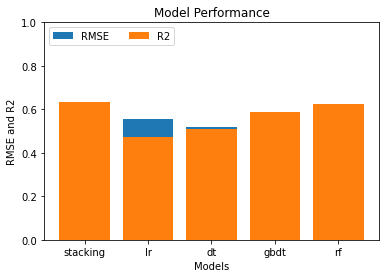

  Model_Name  RMSE_Value
0   stacking    0.385926
1         lr    0.554924
2         dt    0.519205
3       gbdt    0.436445
4         rf    0.396303
  Model_Name  R2_Value
0   stacking  0.634462
1         lr  0.474391
2         dt  0.508223
3       gbdt  0.586611
4         rf  0.624632


In [22]:
RMSE_Results = [rmse, lr_rmse, dt_rmse, gbdt_rmse, rf_rmse]
R2_Results = [r2, lr_r2, dt_r2, gbdt_r2, rf_r2]

rg= np.arange(5)
width = 0.35

# 1. Create bar plot with RMSE results
# YOUR CODE HERE
## Cell 13a -- correct I think
## helpful code source info https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/

model_labels = ["stacking", "lr", "dt", "gbdt", "rf"]

plt.bar(model_labels,RMSE_Results,label="RMSE")
plt.title("RMSE Results")

# 2. Create bar plot with R2 results
# YOUR CODE HERE
## Cell 13b -- correct I think
## code process notes: confused, two different bar charts or two different bars on the same chart?
##  seems like from below code that it should be 1 chart w two bars...

plt.bar(model_labels,R2_Results,label="R2")
plt.title("R-squared Results")

# 3. Call plt.xticks() to add labels under the bars indicating which model the pair of RMSE 
# and R2 bars correspond to
# YOUR CODE HERE
## Cell 13c -- correct!
## code source info useful: https://www.geeksforgeeks.org/python/matplotlib-pyplot-xticks-in-python/
## code process notes hmmm labels = zzz which model = x axis categories labels how to access
##   contd ok maybe it's like Series label in excel plots? I don't have "pretty" list of eg. RMSE, would be 
##       eg. like RMSE_results but RMSE_model = ['rmse', 'lr_rmse']... need to print RMSE_results to see what structure etc
##      solution to try ah indexing? still not a string but a var name in a list hmm
##         ok I'll just create a list with model names as strings that seems clearest
## more references https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html
## had to build labels into the above bar()

model_labels = ["stacking", "lr", "dt", "gbdt", "rf"]

plt.xticks(model_labels)

# 4. Label the x and y axis of the plot: the x axis should be labeled "Models" and the y axis
# should be labeled "RMSE and R2"
# YOUR CODE HERE
## Cell 13d -- done

plt.xlabel('Models')
plt.ylabel('RMSE and R2')           
           
           
plt.ylim([0,1])
plt.title('Model Performance')
plt.legend(loc='upper left', ncol=2)
plt.show()

## needed addtional data tables to compare model performance

RMSE_wModels_DF = pd.DataFrame({'Model_Name': model_labels,'RMSE_Value': RMSE_Results})

R2_wModels_DF = pd.DataFrame({'Model_Name': model_labels,'R2_Value': R2_Results})

print(RMSE_wModels_DF)
print(R2_wModels_DF)


<b>Analysis</b>: Compare the performance of the stacking model with the individual models. Is the stacking model performing better?
Now that you are familiar with the Airbnb data, think about how a regression for price could be improved. What would you change, either at the feature engineering stage, or in the model selection, or at the stage of hyperparameter tuning?
Record your findings in the cell below.

Cell 14 -- finished

Is the stacking model beforming better than the individual models? 
Not significantly. As shown on the bar chart above, and data table, the stacking model's r2 value is close in value to the random forest ("rf") model, a little above 0.60. R2 is the percent of the data explained by the model so higher is better, and the stacked model and random forest model are the models with the two highest r2 scores.  
When mesuring model performance by RMSE, the lower the score is better, less error, and again the stacking model and random forest model have the two lowest RMSE scores among the tested models, as shown above in the data table (0.3859216 vs 0.396303). The bar chart doesn't clearly show the bars for RMSE. It would be much easier to prepare the bar chart if my data were organized as a dataframe instead but then my script would deviate more from the code structure here so I left it as is. I also have a really hard time reading the bar chart as it is but was having a hard time adjusting the plot settings to change the size, and other examples I found of bar charts and formatting didn't look similar enough to this scenario for me to be able to add more code here. That's why I added the data tables. 

What would I change either at the feature engineering stage or in the model selection or in hyperparameter tuning?
I'm not sure I would change anything as in "go back in time" but I think going forward, optimzing the approach may include reducing the complexity of the model to reduce resource consumption. From a practical standpoint, this particular jupyter project took a lot of computational time, and I worked on it 5 or more times. Each time I opend up the notebook again, I'd need to run each cell section because of dependencies (as far as I can tell that is necessary) so there was lots of time waiting for, for example the newer StackingRegressor cell (In[08]) took around 10 minutes to run each time. So if I was in a professional setting I'd want to focus in on the models and computations that are providing the most model performance value. I would consider switching from the stacking model to the random forest model since the results in model performance is similar and the reduction in complexity and computational time seems quite significant. I would be interested in exploring and testing the impact of an optimization like that. 